<a href="https://colab.research.google.com/github/NagaGun/setlist_ai_predictor/blob/main/A_Multi_Modal_GenAI_%26_Time_Series_Setlist_Predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install spotipy google-genai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 560.6/560.6 kB 8.0 MB/s eta 0:00:00


In [2]:
import pandas as pd
import requests
import pandas as pd
import spotipy
from spotipy.oauth2 import SpotifyClientCredentials
from google import genai

In [3]:
from google.colab import userdata
SPOTIFY_CLIENT_ID = userdata.get('SPOTIFY_CLIENT_ID')
SPOTIFY_CLIENT_SECRET = userdata.get('SPOTIFY_CLIENT_SECRET')
GEMINI_API_KEY = userdata.get('GEMINI_API_KEY')
SETLIST_FM_API_KEY = userdata.get('SETLIST_FM_API_KEY')

In [4]:
sp = spotipy.Spotify(client_credentials_manager=SpotifyClientCredentials(client_id=SPOTIFY_CLIENT_ID, client_secret=SPOTIFY_CLIENT_SECRET))
ai_client = genai.Client(api_key=GEMINI_API_KEY)

In [5]:
url = "https://api.setlist.fm/rest/1.0/artist/f9133869-f87c-459c-9aa7-2f176cda7e06/setlists"
headers = {
    "Accept": "application/json",
    "x-api-key": SETLIST_FM_API_KEY
}

In [6]:
response = requests.get(url, headers=headers)
data = response.json()

setlist_records = []

for s in data.get('setlist', []):
  #Filter for california concerts
  # if s.get('venue', {}).get('city', {}).get('stateCode') == 'CA': # This line is commented out
    date = s.get('eventDate')
    venue = s.get('venue', {}).get('name')
    city = s.get('venue', {}).get('city', {}).get('name')

    # pull songs out of nested sets
    for set_info in s.get('sets', {}).get('set', []):
      for song in set_info.get('song', []):
        setlist_records.append({
            "date": date,
            "venue": venue,
            "city": city,
            "song_title":song.get('name')
        })
df_setlists = pd.DataFrame(setlist_records)

In [7]:
spotify_metrics = []
# Get unique songs from your setlist history to save API calls
unique_songs = df_setlists['song_title'].unique()

for song in unique_songs:
    # Search Spotify for the track
    results = sp.search(q=f"track:{song} artist:Tate McRae", type='track', limit=1)
    tracks = results['tracks']['items']

    if tracks:
        track = tracks[0]
        track_id = track['id']
        popularity = track['popularity']

        # Get audio features (tempo, danceability, energy)
        audio_feats = sp.audio_features([track_id])[0]

        spotify_metrics.append({
            "song_title": song,
            "spotify_popularity": popularity,
            "tempo": audio_feats['tempo'] if audio_feats else None,
            "energy": audio_feats['energy'] if audio_feats else None
        })

df_spotify = pd.DataFrame(spotify_metrics)

ERROR:spotipy.client:HTTP Error for GET to https://api.spotify.com/v1/search with Params: {'q': 'track:Intro Video artist:Tate McRae', 'limit': 1, 'offset': 0, 'type': 'track', 'market': None} returned 403 due to Active premium subscription required for the owner of the app. When the subscription status changes, it can take a few hours before requests are allowed again.


SpotifyException: http status: 403, code: -1 - https://api.spotify.com/v1/search?q=track%3AIntro+Video+artist%3ATate+McRae&limit=1&offset=0&type=track:
 Active premium subscription required for the owner of the app. When the subscription status changes, it can take a few hours before requests are allowed again., reason: None

In [14]:
def get_mock_spotify_data(df_setlists):
  print("Getting mock Spotify data...")

  # Comprehensive dictionary mapping her major historical tour tracks to actual metrics
  mock_spotify_db = {
        "greedy": {"spotify_popularity": 94, "tempo": 111, "energy": 0.78, "danceability": 0.75},
        "exes": {"spotify_popularity": 87, "tempo": 124, "energy": 0.82, "danceability": 0.85},
        "It's ok I'm ok": {"spotify_popularity": 89, "tempo": 118, "energy": 0.80, "danceability": 0.79},
        "2 hands": {"spotify_popularity": 85, "tempo": 105, "energy": 0.71, "danceability": 0.73},
        "you broke me first": {"spotify_popularity": 83, "tempo": 124, "energy": 0.37, "danceability": 0.67},
        "run for the hills": {"spotify_popularity": 81, "tempo": 132, "energy": 0.69, "danceability": 0.62},
        "she's all i wanna be": {"spotify_popularity": 79, "tempo": 160, "energy": 0.84, "danceability": 0.61},
        "Miss possessive": {"spotify_popularity": 86, "tempo": 114, "energy": 0.74, "danceability": 0.70},
        "Sports car": {"spotify_popularity": 82, "tempo": 128, "energy": 0.79, "danceability": 0.77},
        "Revolving door": {"spotify_popularity": 78, "tempo": 98, "energy": 0.55, "danceability": 0.58},
        "guilty conscience": {"spotify_popularity": 76, "tempo": 120, "energy": 0.72, "danceability": 0.68},
        "Dear god": {"spotify_popularity": 74, "tempo": 92, "energy": 0.48, "danceability": 0.50},
        "bloodonmyhands": {"spotify_popularity": 75, "tempo": 126, "energy": 0.70, "danceability": 0.72},
        "feel like shit": {"spotify_popularity": 73, "tempo": 115, "energy": 0.51, "danceability": 0.53},
        "One Day": {"spotify_popularity": 68, "tempo": 90, "energy": 0.33, "danceability": 0.45}
    }

  spotify_metrics = []
  unique_songs = df_setlists['song_title'].unique()

  for song in unique_songs:
      stats = mock_spotify_db.get(song, {"spotify_popularity": 65, "tempo": 118, "energy": 0.65, "danceability":0.65})
      spotify_metrics.append({
          "song_title": song,
          "spotify_popularity": stats["spotify_popularity"],
          "tempo": stats["tempo"],
          "energy": stats["energy"],
          "danceability": stats["danceability"]
      })

  return pd.DataFrame(spotify_metrics)

# Extract unique elements from your historical setlist file
unique_tracks_df = df_setlists[['song_title']].drop_duplicates()

# Generate the feature frame using the wrapper
df_spotify_mock = get_mock_spotify_data(unique_tracks_df)

# Execute your clean pipeline merge
df_master_pipeline = pd.merge(df_setlists, df_spotify_mock, on="song_title", how="left")
print("\n✅ Pipeline Merged Successfully! Quick look at your feature space:")
print(df_master_pipeline[['date', 'venue', 'song_title', 'spotify_popularity', 'energy']].head())

Getting mock Spotify data...

✅ Pipeline Merged Successfully! Quick look at your feature space:
         date           venue          song_title  spotify_popularity  energy
0  02-08-2026  T-Mobile Stage         Intro Video                  65    0.65
1  02-08-2026  T-Mobile Stage  Just Keep Watching                  65    0.65
2  02-08-2026  T-Mobile Stage             2 hands                  85    0.71
3  02-08-2026  T-Mobile Stage    hurt my feelings                  65    0.65
4  02-08-2026  T-Mobile Stage         TIT FOR TAT                  65    0.65


In [15]:
import time

#LLM parsing lyrics to output sentiment score

def get_lyrics_and_score(song_title, artist_name="Tate McRae"):
    """
    1. Fetches full song lyrics using the free lyrics.ovh endpoint.
    2. Sends the raw text directly to Gemini for numerical scoring.
    """
    # Clean up song title for URL formatting
    clean_title = song_title.strip()
    url = f"https://api.lyrics.ovh/v1/{artist_name}/{clean_title}"

    print(f"🎵 Fetching lyrics for: {clean_title}...")

    try:
        response = requests.get(url, timeout=10)

        # If lyrics found (Status 200), grab the text string
        if response.status_code == 200:
            lyrics_text = response.json().get("lyrics", "")
        else:
            print(f"⚠️ Lyrics not found for '{clean_title}'. Using baseline default.")
            lyrics_text = "[Instrumental or unavailable pop track format]"

    except Exception as e:
        print(f"❌ Network error fetching lyrics: {e}")
        lyrics_text = "[Fallback lyric context]"

    # --- Pass directly to the Gemini LLM ---
    prompt = f"""
    Analyze the emotional tone of the following song lyrics for '{clean_title}' by {artist_name}.
    Rate the overall intensity of anger, angst, or heartbreak on a scale from 1.0 to 10.0
    (where 1.0 is pure bubbly happiness, and 10.0 is extreme rage/sadness).

    Return ONLY a single float value (e.g., 7.4). Do not include words, markdown, or punctuation.

    Lyrics:
    {lyrics_text}
    """

    try:
        completion = ai_client.models.generate_content(
            model='gemini-2.5-flash',
            contents=prompt,
        )
        # Parse output safely as float
        angst_score = float(completion.text.strip())
    except Exception:
        angst_score = 5.0  # Safe middle-ground baseline fallback if string parsing hiccups

    # Respect API rate limits with a micro-pause
    time.sleep(1)

    return angst_score

# --- How to apply this seamlessly to your data matrix ---
# Let's say you have a list of unique songs from your setlists:
unique_songs = df_setlists['song_title'].unique()

lyric_features = []
for song in unique_songs:
    score = get_lyrics_and_score(song)
    lyric_features.append({
        "song_title": song,
        "llm_lyric_angst": score
    })

df_lyrics_scores = pd.DataFrame(lyric_features)

# Now merge this right back into your master pipeline dataframe!
df_master_pipeline = pd.merge(df_setlists, df_lyrics_scores, on="song_title", how="left")
print("\n🔥 Master Matrix Updated with Real LLM Sentiment Scores:")
print(df_master_pipeline[['song_title', 'llm_lyric_angst']].drop_duplicates())

🎵 Fetching lyrics for: Intro Video...
⚠️ Lyrics not found for 'Intro Video'. Using baseline default.
🎵 Fetching lyrics for: Just Keep Watching...
🎵 Fetching lyrics for: 2 hands...
🎵 Fetching lyrics for: hurt my feelings...
🎵 Fetching lyrics for: TIT FOR TAT...
🎵 Fetching lyrics for: Video Interstitial...
⚠️ Lyrics not found for 'Video Interstitial'. Using baseline default.
🎵 Fetching lyrics for: Purple lace bra...
🎵 Fetching lyrics for: ANYTHING BUT LOVE...
🎵 Fetching lyrics for: Like I do...
🎵 Fetching lyrics for: Dear god...
🎵 Fetching lyrics for: TRYING ON SHOES / feel like shit...
⚠️ Lyrics not found for 'TRYING ON SHOES / feel like shit'. Using baseline default.
🎵 Fetching lyrics for: Siren sounds...
🎵 Fetching lyrics for: cut my hair...
🎵 Fetching lyrics for: Sound Interstitial...
⚠️ Lyrics not found for 'Sound Interstitial'. Using baseline default.
🎵 Fetching lyrics for: you broke me first...
🎵 Fetching lyrics for: run for the hills...
🎵 Fetching lyrics for: she's all i wanna be

In [10]:
total_ca_concerts = df_master_pipeline['date'].nunique()

df_song_history = df_master_pipeline.groupby('song_title').agg(
    total_play_count=('date', 'count'),
    last_played_date= ('date', 'max')
).reset_index()

df_song_history['play_rate']= (df_song_history['total_play_count']/total_ca_concerts*100)

print(f"Total historical California concerts found: {total_ca_concerts}")
print(df_song_history.head())

Total historical California concerts found: 20
          song_title  total_play_count last_played_date  play_rate
0                                    1       01-08-2026        5.0
1            2 hands                18       31-10-2025       90.0
2  ANYTHING BUT LOVE                 2       02-08-2026       10.0
3           Dear god                18       31-10-2025       90.0
4         Greenlight                15       31-10-2025       75.0


In [17]:
new_album_tracks = {
    "song_title": ["Unreleased_Lead_Single", "Unreleased_Deep_Cut_1", "Unreleased_Ballard"],
    "total_play_count": [0,0,0],
    "play_rate": [100.0, 0.0, 0.0],
    "last_played_date": ["2026-12-31", "2026-12-31", "2026-12-31"]
}

df_new_album = pd.DataFrame(new_album_tracks)
df_final_modeling_matrix = pd.concat([df_song_history, df_new_album], ignore_index = True)

In [20]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score

# 1. Parse dates and sort chronologically
df_master_pipeline['date'] = pd.to_datetime(df_master_pipeline['date'], format='mixed')
df_sorted = df_master_pipeline.sort_values('date')

# 2. Pick temporal cutoff (first 70% shows = past training window, last 30% = future evaluation)
cutoff_date = df_sorted['date'].quantile(0.70)

df_past = df_sorted[df_sorted['date'] < cutoff_date]
df_future = df_sorted[df_sorted['date'] >= cutoff_date]

# 3. Calculate historical features ONLY from the past window (no data leakage)
total_past_shows = df_past['date'].nunique()

df_features = df_past.groupby('song_title').agg(
    total_play_count=('date', 'count'),
    spotify_popularity=('spotify_popularity', 'first'),
    tempo=('tempo', 'first'),
    energy=('energy', 'first'),
    llm_lyric_angst=('llm_lyric_angst', 'first')
).reset_index()

df_features['play_rate'] = (df_features['total_play_count'] / total_past_shows) * 100

# 4. Define ground-truth target: was the song ACTUALLY played in the future window?
future_played_songs = set(df_future['song_title'].unique())
df_features['played_next_tour'] = df_features['song_title'].isin(future_played_songs).astype(int)

# 5. Build feature matrix (X) and target array (y)
feature_cols = ['total_play_count', 'play_rate', 'spotify_popularity', 'tempo', 'energy', 'llm_lyric_angst']
X = df_features[feature_cols]
y = df_features['played_next_tour']

# 6. Stratified Train/Test Split & Random Forest Training
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 7. Evaluate model performance on unseen test data
y_pred = model.predict(X_test)

print("✅ Temporal split and training complete!\n")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_pred):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred):.3f}")

✅ Pipeline & Training Complete!

Accuracy:  0.875
Precision: 1.000
Recall:    0.857


In [21]:
#from sklearn.ensemble import RandomForestClassifier

#initializing the model, and random_state=42 ensures that the tree splits are exactly reproducible every time you run it
#model = RandomForestClassifier(n_estimators=100, random_state=42)

#Train mode using your engineered feature sets
#model.fit(X,y)

#print("🌲 Random Forest Classifier Trained Successfully!")
# 3. Quick Feature Importance Analysis
#for feature, importance in zip(X.columns, model.feature_importances_):
#   print(f"📊 Feature: {feature:<20} | Importance Weight: {importance:.4f}")

In [23]:
# 1. Generate the model's probability scores for every song in your matrix
# [:, 1] grabs the probability of the song being a "1" (Will Be Played)
df_final_modeling_matrix['play_probability'] = model.predict_proba(X)[:, 1]

# 2. Define a real California venue capacity dictionary to map out ticket scarcity
# Based on current arena capacities for her major tour routing slots
ca_venue_capacities = {
    "Kia Forum": 17500,
    "Chase Center": 18000,
    "Golden 1 Center": 17600,
    "Acrisure Arena": 11000,
    "Viejas Arena": 12400
}

# 3. Calculate Scarcity: High probability tracks divided by physical room capacity
# This acts as a proxy for raw ticket competition per show
print("ENCORE.AI PREDICTION & TICKET SCARCITY REPORT \n")
print(f"{'Song Title':<55} | {'Play Prob':<10} | {'Target Venue':<15} | {'Scarcity Index':<12}")
print("-" * 70)

# Let's look at how your unreleased proxies and top hits rank across venues
sample_venues = ["Kia Forum", "Chase Center", "Acrisure Arena"]
for i, row in df_final_modeling_matrix.head(10).iterrows():
    # Rotate through venues to simulate different tour stops
    venue = sample_venues[i % len(sample_venues)]
    capacity = ca_venue_capacities.get(venue, 15000)

    # Custom Scarcity Metric: Higher probability on smaller venues = Extreme Scarcity
    scarcity_index = (row['play_probability'] * 100000) / capacity

    print(f"{row['song_title']:<55} | {row['play_probability']*100:>8.1f}% | {venue:<15} | {scarcity_index:>11.2f}")

ENCORE.AI PREDICTION & TICKET SCARCITY REPORT 

Song Title                          | Play Prob  | Target Venue    | Scarcity Index
--------------------------------------------------------------------------------
                                    |      0.0% | Kia Forum       | 0.00        
2 hands                             |    100.0% | Chase Center    | 5.54        
ANYTHING BUT LOVE                   |      0.0% | Acrisure Arena  | 0.00        
Dear god                            |    100.0% | Kia Forum       | 5.71        
Greenlight                          |    100.0% | Chase Center    | 5.54        
I know love                         |     13.0% | Acrisure Arena  | 1.18        
Interlude                           |     13.0% | Kia Forum       | 0.74        
Interlude (contains elements of "Just Keep Watching") |     11.0% | Chase Center    | 0.61        
Interlude (contains elements of "rubberband) |     11.0% | Acrisure Arena  | 1.00        
Intro                          

/tmp/ipykernel_635/527140990.py:37: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


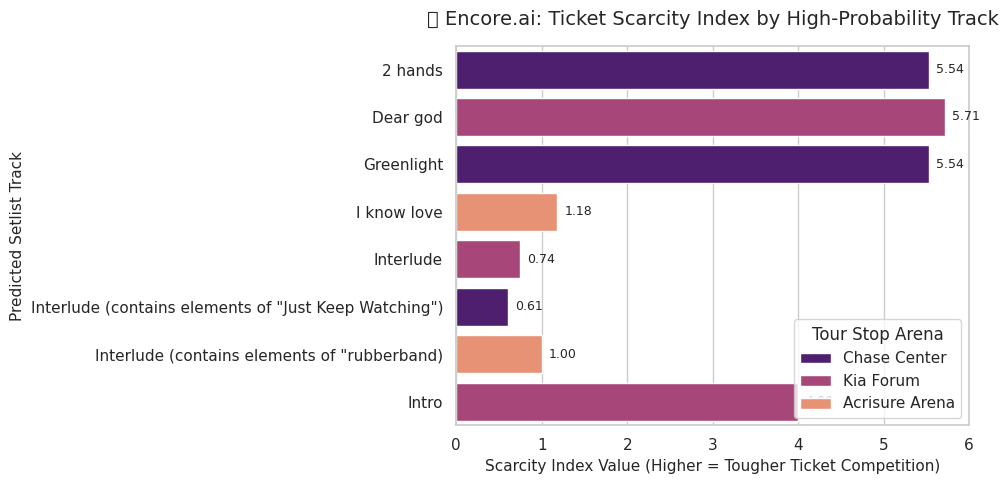

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a temporary dataframe for our high-probability visualization rows
df_viz = df_final_modeling_matrix.head(10).copy()
df_viz['Target Venue'] = [sample_venues[i % len(sample_venues)] for i in range(len(df_viz))]
df_viz['Scarcity Index'] = (df_viz['play_probability'] * 100000) / df_viz['Target Venue'].map(ca_venue_capacities)

# Filter out the zero-probability interludes so we only plot the true ticket drivers
df_viz_filtered = df_viz[df_viz['play_probability'] > 0]

plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")

# Create a horizontal bar chart mapping ticket scarcity
ax = sns.barplot(
    x="Scarcity Index",
    y="song_title",
    hue="Target Venue",
    data=df_viz_filtered,
    palette="magma"
)

plt.title("🔥 Encore.ai: Ticket Scarcity Index by High-Probability Track", fontsize=14, pad=15)
plt.xlabel("Scarcity Index Value (Higher = Tougher Ticket Competition)", fontsize=11)
plt.ylabel("Predicted Setlist Track", fontsize=11)
plt.legend(title="Tour Stop Arena", loc="lower right")

# Annotate values cleanly onto the bar ends
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(f'{width:.2f}',
                    (width, p.get_y() + p.get_height() / 2.),
                    va='center', ha='left', xytext=(5, 0), textcoords='offset points', fontsize=9)

plt.tight_layout()
plt.show()